# Acrobot iLQR-MPC — Receding-Horizon Online Optimiser

**Concept:** At every timestep the MuJoCo plant yields the current state.
iLQR solves an optimisation problem over a short look-ahead horizon,
only the first control is applied, and the whole process repeats.
This is **Model Predictive Control (MPC)** with iLQR as the inner solver.

**Cell overview:**
| Cell | Contents |
|------|----------|
| 1 | Imports |
| 2 | All parameters, initial conditions, cost matrices ← **edit here** |
| 3 | MuJoCo helpers (`load_mujoco`, `get_state`, `set_state`, `apply_control_and_step`) |
| 4 | Acrobot dynamics (RK4), cost functions, iLQR backward/forward passes |
| 5 | `run_mpc` — receding-horizon loop |
| 6 | Execute: single `run_mpc(...)` call |
| 7 | Results plots |
| 8 | Meshcat visualisation (Drake) |



In [1]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 1 — Imports
# ═══════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import mujoco
import time
from IPython.display import HTML

%matplotlib inline

In [2]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 2 — ALL Parameters, Initial Conditions & Cost Matrices
#           ← Edit ONLY this cell to tune the controller
# ═══════════════════════════════════════════════════════════════════════

# I1: 0.000277196
# I2: 0.000147456
# Ir: 6.1e-06
# b1: 0.0004
# b2: 0.0004
# cf1: 0.0030535619759663626
# cf2: 0.0007777171177173469
# g: 9.81
# gr: 1.0
# l1: 0.05
# l2: 0.05
# m1: 0.134
# m2: 0.064
# r1: 0.046
# r2: 0.048
# tl1: 0.15
# tl2: 0.15

# ── File path ──────────────────────────────────────────────────────────
XML_PATH = 'Acrobot2.xml'

# ── Physical parameters (must match acrobot.xml exactly) ──────────────
m1, m2 = 0.134,    0.064
l1, l2 = 0.05,                   0.05
r1, r2 = 0.046,                   0.048
I1, I2 = 0.000277196, 0.000147456
g       = 9.81                   # gravity [m/s²]
b1      = 0.0004
b2      = 0.0004  # elbow viscous damping [Nm·s/rad]
cf1     = 0.0030535619759663626  # shoulder Coulomb friction [Nm]
cf2     = 0.0007777171177173469  # elbow   Coulomb friction [Nm]

J1 = I1 + m1 * r1**2            # effective inertia, link 1
J2 = I2 + m2 * r2**2            # effective inertia, link 2

# ── Timing ─────────────────────────────────────────────────────────────
dt           = 0.02              # iLQR / RK4 control timestep [s]
STEPS_PER_DT = 20                # MuJoCo micro-steps per iLQR step

# ── MPC settings ───────────────────────────────────────────────────────
N_MPC    = 40                    # receding-horizon look-ahead (= 0.8 s)
MAX_ITER = 10                    # iLQR iterations per MPC step
REGU0    = 10.0                  # initial Q_uu regularisation
T_SIM    = 8.0                   # total simulation duration [s]

# ── Goal & cost matrices ───────────────────────────────────────────────
x_goal = np.array([np.pi, 0.0, 0.0, 0.0])   # upright equilibrium

Q  = np.diag([1.0,  0.3,  0.5,  0.1])      # running state cost
R  = np.array([[0.0001]])                      # control effort cost
Qf = np.diag([5000., 2000., 700., 700.])          # terminal state cost

# ── Torque limit ────────────────────────────────────────────────────────
# tanh squashing lives ONLY inside acrobot_continuous().
# run_mpc sends raw iLQR output directly; no second tanh.
TORQUE_LIMIT = 0.15              # [Nm] — must match <actuator ctrlrange> in acrobot.xml

# ── Initial state & warm-start ─────────────────────────────────────────
x0         = np.array([-1e-6, 0.0, 0.0, 0.0])  # near downward rest
u_trj_init = np.full((N_MPC, 1), 0.1)           # shape must be (N_MPC, 1)

print("─" * 60)
print(f"  XML        : {XML_PATH}")
print(f"  dt         : {dt} s   |  MuJoCo steps/dt : {STEPS_PER_DT}")
print(f"  Horizon    : {N_MPC} steps = {N_MPC*dt:.2f} s")
print(f"  Simulation : {T_SIM} s  ({int(T_SIM/dt)} MPC steps)")
print(f"  iLQR iters : {MAX_ITER}   |  regu0 : {REGU0}")
print(f"  Torque lim : ±{TORQUE_LIMIT} Nm")
print(f"  x0         : {x0}")
print(f"  x_goal     : {x_goal}")
print(f"  u_trj_init shape : {u_trj_init.shape}   ← must be (N_MPC, 1)")
print("─" * 60)

────────────────────────────────────────────────────────────
  XML        : Acrobot2.xml
  dt         : 0.02 s   |  MuJoCo steps/dt : 20
  Horizon    : 40 steps = 0.80 s
  Simulation : 8.0 s  (400 MPC steps)
  iLQR iters : 10   |  regu0 : 10.0
  Torque lim : ±0.15 Nm
  x0         : [-1.e-06  0.e+00  0.e+00  0.e+00]
  x_goal     : [3.14159265 0.         0.         0.        ]
  u_trj_init shape : (40, 1)   ← must be (N_MPC, 1)
────────────────────────────────────────────────────────────


In [3]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 3 — MuJoCo Setup & State Interface
# ═══════════════════════════════════════════════════════════════════════

def load_mujoco(xml_path=XML_PATH):
    model = mujoco.MjModel.from_xml_path(xml_path)
    data  = mujoco.MjData(model)
    return model, data


def get_state(data):
    """MuJoCo → iLQR state vector [q1, q2, dq1, dq2]."""
    return np.array([data.qpos[0], data.qpos[1],
                     data.qvel[0], data.qvel[1]])


def set_state(model, data, x):
    """Write iLQR state vector into MuJoCo and call mj_forward."""
    data.qpos[0] = x[0]
    data.qpos[1] = x[1]
    data.qvel[0] = x[2]
    data.qvel[1] = x[3]
    mujoco.mj_forward(model, data)


def apply_control_and_step(model, data, u_scalar, n_steps=STEPS_PER_DT):
    """
    Apply elbow torque u_scalar and advance MuJoCo by one iLQR timestep.
    ctrl[0] maps to the single actuator on the elbow joint.
    """
    data.ctrl[0] = float(u_scalar)
    for _ in range(n_steps):
        mujoco.mj_step(model, data)


# ── Quick sanity check ─────────────────────────────────────────────────
_m, _d = load_mujoco()
print(f"MuJoCo loaded  : {_m.nq} DoF, {_m.nu} actuator(s)")
print(f"  Actuators    : {[_m.actuator(i).name for i in range(_m.nu)]}")
print(f"  Joints       : {[_m.joint(i).name for i in range(_m.njnt)]}")
print(f"  MuJoCo dt    : {_m.opt.timestep} s")
print(f"  iLQR dt      : {STEPS_PER_DT} × {_m.opt.timestep} s = {STEPS_PER_DT * _m.opt.timestep} s")
del _m, _d

MuJoCo loaded  : 2 DoF, 1 actuator(s)
  Actuators    : ['elbow_motor']
  Joints       : ['shoulder', 'elbow']
  MuJoCo dt    : 0.001 s
  iLQR dt      : 20 × 0.001 s = 0.02 s


In [4]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 4 — Acrobot Dynamics · RK4 · iLQR Building Blocks
# ═══════════════════════════════════════════════════════════════════════

def acrobot_continuous(x, u):
    """Continuous-time acrobot equations of motion with smooth Coulomb friction."""
    q1, q2, dq1, dq2 = x[0], x[1], x[2], x[3]
    tau2    = u[0]
    EPS_VEL = 0.01   # tanh smoothing width [rad/s]

    # Guard: clip velocities to prevent overflow in Coriolis/centrifugal terms
    dq1 = float(np.clip(dq1, -29.0, 29.0))
    dq2 = float(np.clip(dq2, -29.0, 29.0))

    M11 = J1 + J2 + m2*(l1**2 + 2*l1*r2*np.cos(q2))
    M12 = J2 + m2*l1*r2*np.cos(q2)
    M22 = J2
    h   = m2*l1*r2*np.sin(q2)
    c1  = -2*h*dq2*dq1 - h*dq2**2
    c2  =  h*dq1**2
    G1  = g*(m1*r1 + m2*l1)*np.sin(q1) + g*m2*r2*np.sin(q1+q2)
    G2  = g*m2*r2*np.sin(q1+q2)
    rhs1 = 0    - c1 - G1 - b1*dq1 - cf1*np.tanh(dq1/EPS_VEL)
    rhs2 = tau2 - c2 - G2 - b2*dq2 - cf2*np.tanh(dq2/EPS_VEL)
    det  = M11*M22 - M12**2
    ddq1 = (M22*rhs1 - M12*rhs2) / det
    ddq2 = (M11*rhs2 - M12*rhs1) / det
    return np.array([dq1, dq2, ddq1, ddq2])


def acrobot_discrete_RK4(x, u):
    """RK4 integration over one iLQR timestep dt."""
    k1 = acrobot_continuous(x, u)
    k2 = acrobot_continuous(x + dt/2*k1, u)
    k3 = acrobot_continuous(x + dt/2*k2, u)
    k4 = acrobot_continuous(x + dt  *k3, u)
    return x + dt/6*(k1 + 2*k2 + 2*k3 + k4)


# ── Angle wrapping & cost functions ─────────────────────────────────────
def wrap_angle(theta):
    """Wrap angle to [−π, π]."""
    return (theta + np.pi) % (2*np.pi) - np.pi


def angle_error(x):
    """State error with q1, q2 wrapped to [−π, π]."""
    dx = x - x_goal
    dx[0] = wrap_angle(dx[0])
    dx[1] = wrap_angle(dx[1])
    return dx


def stage_cost(x, u):
    dx = angle_error(x.copy())
    return float(dx @ Q @ dx + u @ R @ u)


def stage_cost_derivatives(x, u):
    dx   = angle_error(x.copy())
    l_x  = 2.0 * Q @ dx
    l_u  = 2.0 * R @ u
    l_xx = 2.0 * Q
    l_ux = np.zeros((R.shape[0], Q.shape[0]))
    l_uu = 2.0 * R
    return l_x, l_u, l_xx, l_ux, l_uu


def final_cost(x):
    dx = angle_error(x.copy())
    return float(dx @ Qf @ dx)


def final_cost_derivatives(x):
    dx = angle_error(x.copy())
    return 2.0 * Qf @ dx, 2.0 * Qf


def init_value_function(x_terminal):
    return final_cost_derivatives(x_terminal)


def update_value_function(Q_x, Q_xx, Q_uu, K, k):
    V_x  = Q_x  - K.T @ Q_uu @ k
    V_xx = Q_xx - K.T @ Q_uu @ K
    return V_x, V_xx


# ── Dynamics Jacobians (central finite differences) ──────────────────────
def f_x(x, u, eps=1e-5):
    n = len(x)
    J = np.zeros((n, n))
    for i in range(n):
        xp, xm = x.copy(), x.copy()
        xp[i] += eps; xm[i] -= eps
        J[:, i] = (acrobot_discrete_RK4(xp, u) -
                   acrobot_discrete_RK4(xm, u)) / (2*eps)
    return J


def f_u(x, u, eps=1e-5):
    m, n = len(u), len(x)
    J = np.zeros((n, m))
    for i in range(m):
        up, um = u.copy(), u.copy()
        up[i] += eps; um[i] -= eps
        J[:, i] = (acrobot_discrete_RK4(x, up) -
                   acrobot_discrete_RK4(x, um)) / (2*eps)
    return J


# ── Q-function assembly & gains ──────────────────────────────────────────
def Q_terms(l_x, l_u, l_xx, l_ux, l_uu, Fx, Fu, V_x, V_xx):
    Q_x  = l_x  + Fx.T @ V_x
    Q_u  = l_u  + Fu.T @ V_x
    Q_xx = l_xx + Fx.T @ V_xx @ Fx
    Q_ux = l_ux + Fu.T @ V_xx @ Fx
    Q_uu = l_uu + Fu.T @ V_xx @ Fu
    return Q_x, Q_u, Q_xx, Q_ux, Q_uu


def compute_gains(Q_uu, Q_u, Q_ux):
    Q_uu_inv = np.linalg.inv(Q_uu)
    k = -Q_uu_inv @ Q_u
    K = -Q_uu_inv @ Q_ux
    return k, K


# ── Trajectory helpers ───────────────────────────────────────────────────
def rollout(x0, u_trj):
    N = u_trj.shape[0]
    x_trj = np.zeros((N+1, 4))
    x_trj[0] = x0
    for n in range(N):
        x_trj[n+1] = acrobot_discrete_RK4(x_trj[n], u_trj[n])
    return x_trj


def cost_trj(x_trj, u_trj):
    J = sum(stage_cost(x_trj[n], u_trj[n]) for n in range(u_trj.shape[0]))
    return J + final_cost(x_trj[-1])


# ── iLQR Backward Pass ───────────────────────────────────────────────────
def backward_pass(x_trj, u_trj, regu=1.0):
    N = u_trj.shape[0]
    K_trj = np.zeros((N, 1, 4))
    k_trj = np.zeros((N, 1))
    expected_cost_redu = 0.0
    V_x, V_xx = init_value_function(x_trj[-1])

    for n in range(N-1, -1, -1):
        l_x, l_u, l_xx, l_ux, l_uu = stage_cost_derivatives(x_trj[n].copy(), u_trj[n])
        Fx = f_x(x_trj[n], u_trj[n])
        Fu = f_u(x_trj[n], u_trj[n])
        Qx, Qu, Qxx, Qux, Quu = Q_terms(l_x, l_u, l_xx, l_ux, l_uu, Fx, Fu, V_x, V_xx)

        # Adaptive regularisation until Q_uu is positive-definite
        regu_local = regu
        for _ in range(10):
            Quu_reg = Quu + regu_local * np.eye(1)
            if np.all(np.isfinite(Quu_reg)) and Quu_reg[0, 0] > 1e-8:
                break
            regu_local *= 5.0

        k, K = compute_gains(Quu_reg, Qu, Qux)

        # Bail out if gains are still NaN
        if not np.all(np.isfinite(k)) or not np.all(np.isfinite(K)):
            return k_trj, K_trj, 0.0

        k_trj[n] = k
        K_trj[n] = K
        V_x, V_xx = update_value_function(Qx, Qxx, Quu, K, k)

        # Clip V_xx to prevent exponential blow-up over long horizons
        V_xx = np.clip(V_xx, -1e8, 1e8)

        expected_cost_redu += float(-Qu @ k - 0.5 * k @ Quu @ k)

    return k_trj, K_trj, expected_cost_redu


# ── iLQR Forward Pass ────────────────────────────────────────────────────
def forward_pass(x_trj, u_trj, k_trj, K_trj, alpha=1.0):
    N = u_trj.shape[0]
    x_new = np.zeros_like(x_trj)
    u_new = np.zeros_like(u_trj)
    x_new[0] = x_trj[0]
    for n in range(N):
        u_new[n] = u_trj[n] + alpha*k_trj[n] + K_trj[n] @ (x_new[n] - x_trj[n])
        x_new[n+1] = acrobot_discrete_RK4(x_new[n], u_new[n])
    return x_new, u_new


# ── iLQR Main Loop ───────────────────────────────────────────────────────
def run_ilqr(x0, N=50, max_iter=5, regu_init=10.0, tol=1e-3, init_u_trj=None):
    u_trj = init_u_trj.copy() if init_u_trj is not None else np.zeros((N, 1))
    x_trj = rollout(x0, u_trj)
    if not np.all(np.isfinite(x_trj)):
        u_trj = np.zeros((N, 1))
        x_trj = rollout(x0, u_trj)
    regu  = regu_init
    costs = [cost_trj(x_trj, u_trj)]

    for _ in range(max_iter):
        k_trj, K_trj, _ = backward_pass(x_trj, u_trj, regu)
        accepted = False
        for alpha in [1.0, 0.5, 0.25, 0.125, 0.0625]:
            x_new, u_new = forward_pass(x_trj, u_trj, k_trj, K_trj, alpha)
            c_new = cost_trj(x_new, u_new)
            if c_new < costs[-1]:
                x_trj, u_trj = x_new, u_new
                costs.append(c_new)
                regu     = max(regu * 0.7, 1e-6)
                accepted = True
                break
        if not accepted:
            regu = min(regu * 2.0, 1e6)
        if len(costs) > 1 and abs(costs[-1] - costs[-2]) < tol:
            break

    return x_trj, u_trj, costs


print("iLQR functions defined.")
print(f"  RK4 sanity check (zero state/input): {np.round(acrobot_discrete_RK4(np.zeros(4), np.zeros(1)), 6)}")

iLQR functions defined.
  RK4 sanity check (zero state/input): [0. 0. 0. 0.]


In [5]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 5 — iLQR-MPC Receding-Horizon Loop
# ═══════════════════════════════════════════════════════════════════════

def run_mpc(model, data, x0,
            T_sim=T_SIM, N_mpc=N_MPC, max_iter=MAX_ITER,
            regu_init=REGU0, u_trj_init=None):
    """
    Receding-horizon MPC using iLQR as the inner solver.

    At each step:
      1. Read current state from MuJoCo.
      2. Shift the warm-start trajectory by one step.
      3. Run iLQR for `max_iter` iterations on the N_mpc-step horizon.
      4. Apply the first control to MuJoCo and advance.

    Returns
    -------
    x_hist    : (n_steps+1, 4)  state trajectory
    u_hist    : (n_steps, 1)    applied controls
    cost_hist : (n_steps,)      iLQR cost at each step
    time_hist : (n_steps,)      wall-clock solve time [s]
    """
    set_state(model, data, x0)
    n_steps = int(T_sim / dt)

    x_hist    = np.zeros((n_steps + 1, 4))
    u_hist    = np.zeros((n_steps, 1))
    cost_hist = np.zeros(n_steps)
    time_hist = np.zeros(n_steps)

    x_hist[0] = get_state(data)

    if u_trj_init is None:
        u_trj = np.full((N_mpc, 1), 0.01)
    else:
        u_trj = np.array(u_trj_init, dtype=float)
        if u_trj.shape != (N_mpc, 1):
            raise ValueError(
                f"u_trj_init must have shape ({N_mpc}, 1), got {u_trj.shape}."
            )

    print(f"iLQR-MPC started : {n_steps} steps × {dt} s = {T_sim} s")
    print(f"  Horizon        : {N_mpc} steps ({N_mpc*dt:.2f} s)")
    print(f"  iLQR iters/step: {max_iter}")
    print(f"  u_trj shape    : {u_trj.shape}\n")

    for step in range(n_steps):
        x_cur = get_state(data)
        err   = angle_error(x_cur.copy())

        t0 = time.perf_counter()

        # Shift warm-start: drop oldest step, repeat last step
        u_trj = np.vstack([u_trj[1:], u_trj[-1:]])

        x_trj, u_trj, ilqr_costs = run_ilqr(
            x_cur, N=N_mpc, max_iter=max_iter,
            regu_init=regu_init, tol=1e-3,
            init_u_trj=u_trj,
        )
        u0 = float(np.clip(u_trj[0, 0], -TORQUE_LIMIT, TORQUE_LIMIT))

        solve_t = time.perf_counter() - t0

        apply_control_and_step(model, data, u0)

        x_hist[step + 1] = get_state(data)
        u_hist[step]      = u0
        cost_hist[step]   = ilqr_costs[-1]
        time_hist[step]   = solve_t

        if step % 20 == 0:
            err_norm = np.linalg.norm(err)
            print(f"  step {step:4d}/{n_steps} | "
                  f"err={err_norm:.3f} rad | "
                  f"solve={solve_t*1e3:6.1f} ms | "
                  f"u={u0:+.4f} Nm")

    print(f"\nDone.")
    print(f"  Mean solve time  : {time_hist.mean()*1e3:.1f} ms/step")
    print(f"  Final state      : {np.round(x_hist[-1], 3)}")
    print(f"  Goal             : {x_goal}")
    print(f"  Final error norm : {np.linalg.norm(angle_error(x_hist[-1])):.4f} rad")
    return x_hist, u_hist, cost_hist, time_hist


print("run_mpc defined.")

run_mpc defined.


In [6]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 6 — Execute Simulation
# ═══════════════════════════════════════════════════════════════════════
model, data = load_mujoco()

x_hist, u_hist, cost_hist, time_hist = run_mpc(
    model, data, x0,
    T_sim=T_SIM, N_mpc=N_MPC, max_iter=MAX_ITER,
    regu_init=REGU0, u_trj_init=u_trj_init,
)

T_vec = np.arange(len(x_hist)) * dt
U_vec = np.arange(len(u_hist)) * dt

iLQR-MPC started : 400 steps × 0.02 s = 8.0 s
  Horizon        : 40 steps (0.80 s)
  iLQR iters/step: 10
  u_trj shape    : (40, 1)

  step    0/400 | err=3.142 rad | solve= 240.7 ms | u=+0.1500 Nm
  step   20/400 | err=27.693 rad | solve= 154.1 ms | u=-0.0933 Nm
  step   40/400 | err=17.229 rad | solve= 165.2 ms | u=-0.0603 Nm
  step   60/400 | err=18.569 rad | solve= 136.4 ms | u=+0.0652 Nm
  step   80/400 | err=12.595 rad | solve= 149.7 ms | u=-0.0600 Nm
  step  100/400 | err=6.052 rad | solve= 156.9 ms | u=+0.1500 Nm
  step  120/400 | err=23.509 rad | solve= 178.0 ms | u=-0.0416 Nm
  step  140/400 | err=22.180 rad | solve= 163.8 ms | u=-0.0904 Nm
  step  160/400 | err=12.801 rad | solve=  78.0 ms | u=-0.0016 Nm
  step  180/400 | err=12.696 rad | solve=  81.8 ms | u=-0.0043 Nm
  step  200/400 | err=9.014 rad | solve= 168.5 ms | u=+0.0690 Nm
  step  220/400 | err=2.376 rad | solve= 176.5 ms | u=+0.0179 Nm
  step  240/400 | err=0.796 rad | solve= 170.5 ms | u=+0.0082 Nm
  step  260/40

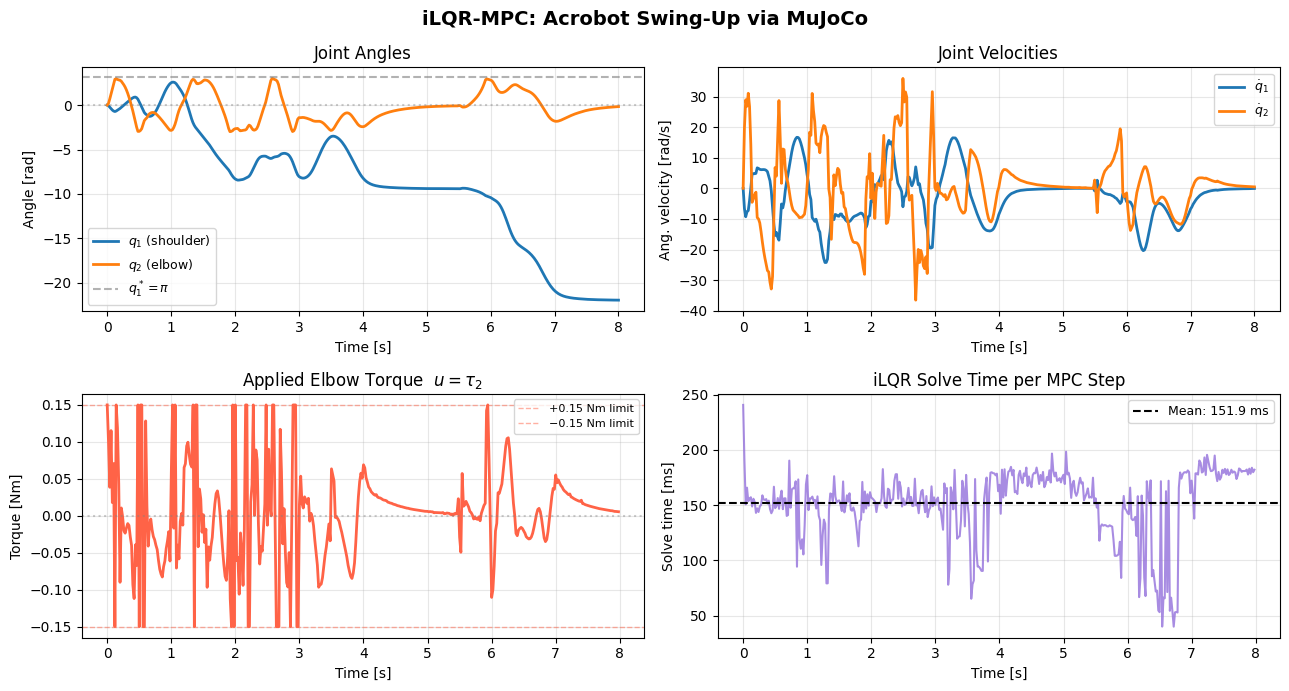

In [7]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 7 — Results Plots
# ═══════════════════════════════════════════════════════════════════════
fig, axs = plt.subplots(2, 2, figsize=(13, 7))

# Joint angles
axs[0, 0].plot(T_vec, x_hist[:, 0], lw=2, label=r'$q_1$ (shoulder)')
axs[0, 0].plot(T_vec, x_hist[:, 1], lw=2, label=r'$q_2$ (elbow)')
axs[0, 0].axhline(np.pi, color='gray', ls='--', alpha=0.6, label=r'$q_1^*=\pi$')
axs[0, 0].axhline(0.0,   color='gray', ls=':',  alpha=0.4)
axs[0, 0].set_xlabel('Time [s]'); axs[0, 0].set_ylabel('Angle [rad]')
axs[0, 0].set_title('Joint Angles'); axs[0, 0].legend(fontsize=9)
axs[0, 0].grid(alpha=0.3)

# Joint velocities
axs[0, 1].plot(T_vec, x_hist[:, 2], lw=2, label=r'$\dot{q}_1$')
axs[0, 1].plot(T_vec, x_hist[:, 3], lw=2, label=r'$\dot{q}_2$')
axs[0, 1].set_xlabel('Time [s]'); axs[0, 1].set_ylabel('Ang. velocity [rad/s]')
axs[0, 1].set_title('Joint Velocities'); axs[0, 1].legend(fontsize=9)
axs[0, 1].grid(alpha=0.3)

# Applied torque
axs[1, 0].plot(U_vec, u_hist[:, 0], lw=2, color='tomato')
axs[1, 0].axhline( TORQUE_LIMIT, color='tomato', ls='--', alpha=0.5, lw=1,
                   label=f'+{TORQUE_LIMIT} Nm limit')
axs[1, 0].axhline(-TORQUE_LIMIT, color='tomato', ls='--', alpha=0.5, lw=1,
                   label=f'\u2212{TORQUE_LIMIT} Nm limit')
axs[1, 0].axhline(0, color='gray', ls=':', alpha=0.4)
axs[1, 0].set_xlabel('Time [s]'); axs[1, 0].set_ylabel('Torque [Nm]')
axs[1, 0].set_title(r'Applied Elbow Torque  $u = \tau_2$')
axs[1, 0].legend(fontsize=8); axs[1, 0].grid(alpha=0.3)

# iLQR solve time
axs[1, 1].plot(U_vec, time_hist * 1e3, lw=1.5, color='mediumpurple', alpha=0.8)
axs[1, 1].axhline(time_hist.mean() * 1e3, color='k', ls='--', lw=1.5,
                   label=f'Mean: {time_hist.mean()*1e3:.1f} ms')
axs[1, 1].set_xlabel('Time [s]'); axs[1, 1].set_ylabel('Solve time [ms]')
axs[1, 1].set_title('iLQR Solve Time per MPC Step')
axs[1, 1].legend(fontsize=9); axs[1, 1].grid(alpha=0.3)

plt.suptitle('iLQR-MPC: Acrobot Swing-Up via MuJoCo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 8 — Meshcat Visualisation (Drake)
#          Replays the MPC state history in the browser via Meshcat.
# ═══════════════════════════════════════════════════════════════════════
from pydrake.all import (
    StartMeshcat,
    MeshcatVisualizer,
    DiagramBuilder,
    AddMultibodyPlantSceneGraph,
    Parser,
)
from underactuated import ConfigureParser
from IPython.display import IFrame, display


def build_meshcat_visualizer(xml_path=XML_PATH):
    meshcat  = StartMeshcat()
    builder  = DiagramBuilder()
    plant, scene_graph = AddMultibodyPlantSceneGraph(builder, time_step=0.0)
    parser   = Parser(plant)
    ConfigureParser(parser)
    parser.AddModels(xml_path)
    plant.Finalize()
    MeshcatVisualizer.AddToBuilder(builder, scene_graph, meshcat)
    diagram  = builder.Build()
    context  = diagram.CreateDefaultContext()
    plant_ctx = plant.GetMyMutableContextFromRoot(context)
    return meshcat, diagram, context, plant, plant_ctx


def animate_mpc(x_hist, sim_dt=dt, xml_path=XML_PATH, sleep_scale=1.0):
    """
    Replay MPC state history in Meshcat.

    Parameters
    ----------
    sleep_scale : float
        1.0 = real-time playback, 0.5 = 2× faster.
    """
    meshcat, diagram, context, plant, plant_ctx = build_meshcat_visualizer(xml_path)
    try:
        display(IFrame(meshcat.web_url(), width='100%', height=450))
    except Exception:
        print("Open Meshcat at:", meshcat.web_url())

    meshcat.StartRecording()
    for t, x in zip(np.arange(len(x_hist)) * sim_dt, x_hist):
        context.SetTime(float(t))
        plant.SetPositions(plant_ctx, x[:2])
        diagram.ForcedPublish(context)
        time.sleep(sim_dt * sleep_scale)
    meshcat.StopRecording()
    meshcat.PublishRecording()
    return meshcat


meshcat = animate_mpc(x_hist)

INFO:drake:Meshcat listening for connections at http://localhost:7000
